# Computer Exercise 14.4 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 14.4 Transfer Case Study — *Recalibrating prediction intervals on a shifted-noise domain*
> **풀이 일자**: 2026-07-04 · **언어**: 한국어 (그래프 라벨은 영문)

§14.3에서 만든 예측구간(PI)은 **균일분산(homoscedastic)** 잔차를 가정했다. 새 도메인의 잡음이
위치에 따라 변하는 **이분산(heteroscedastic)** 이면, 이식한 PI는 피복률이 무너진다. 그 진단과 재보정을 다룬다.

## 1. 문제 (원문)

> **2.** The source pipeline builds a $100(1-\alpha)\%$ prediction interval assuming homoscedastic residuals,
> $\hat y_\star \pm z_{1-\alpha/2}\,\hat\sigma\sqrt{1+h_\star}$. Transfer this recipe to a target domain whose
> noise level **grows with $x$**. Measure the empirical coverage as a function of $x$, show where the
> homoscedastic interval over- and under-covers, and build a **heteroscedastic-aware** interval that restores
> coverage near the nominal level.

### 한국어 풀이용 정리
- target은 잡음 표준편차 $\sigma(x)$ 가 $x$ 에 따라 증가하는 이분산 도메인.
- (a) **이식한 균일분산 PI** 와 (b) **국소분산을 추정한 이분산 PI** 두 가지를 만든다.
- 몬테카를로로 위치별 **경험적 피복률**을 재고, 목표 0.90 대비 어디서 무너지는지 본다.

## 2. 수학적 배경

### 2.1 예측분산의 분해
새 점 $x_\star$ 에서 예측오차 $y_\star-\hat y_\star$ 의 분산은 **관측잡음(aleatoric)** 과 **평균모형 불확실성(epistemic)** 의 합:
$$\mathrm{Var}(y_\star-\hat y_\star)=\underbrace{\sigma^2(x_\star)}_{\text{noise}}+\underbrace{\sigma^2\,h_\star}_{\text{fit uncertainty}},\qquad
h_\star=x_\star^{\top}(X^\top X)^{-1}x_\star .$$

### 2.2 두 가지 PI
$$\text{(homo)}\quad \hat y_\star\pm z\,\hat\sigma\sqrt{1+h_\star},\qquad\qquad
\text{(hetero)}\quad \hat y_\star\pm z\,\sqrt{\hat\sigma^2(x_\star)+\hat\sigma^2 h_\star}.$$
균일분산 PI는 폭이 사실상 상수(가장자리에서 $h_\star$ 로 약간 넓어짐)라, $\sigma(x)$ 가 변하면 폭이 잡음을 못 따라간다.

### 2.3 분산함수 추정
잔차로부터 $\ln r_i^2$ 를 $x$ 에 대해 선형회귀해 $\hat\sigma^2(x)=\exp(\hat\gamma_0+\hat\gamma_1 x)$ 로 국소 잡음을 복원한다(양수 보장).
$\varepsilon\sim N(0,\sigma^2)$ 이면 $\mathbb E[\ln\varepsilon^2]=\ln\sigma^2-1.2704$ (log-$\chi^2_1$ 편의)이므로, 회귀 절편에 **$+1.2704$ 보정**을 더해야 밴드가 과소추정되지 않는다.
$$\boxed{\;\text{균일분산 가정을 그대로 전이하면 고잡음 영역에서 } \textbf{under-cover},\ \text{저잡음 영역에서 } \textbf{over-cover}.\;}$$

## 3. 풀이 흐름

1. **이분산 target 정의**: 참함수 $f$ 와 $x$ 증가에 따라 커지는 $\sigma(x)$ 샘플러.
2. **평균모형 적합**: 4차 다항 최소제곱, 잔차·레버리지 $h(x)$ 계산.
3. **균일분산 PI**: source 방식 그대로 $\hat\sigma\sqrt{1+h}$.
4. **분산함수 추정**: $\ln r^2 \sim x$ 회귀로 $\hat\sigma^2(x)$ 복원.
5. **이분산 PI**: $\sqrt{\hat\sigma^2(x)+\hat\sigma^2 h}$.
6. **몬테카를로 피복률**: 각 $x_\star$ 에서 새 표본을 반복 생성해 구간 포함 여부 집계.
7. **저잡음/고잡음 영역 요약** + 밴드·피복률 시각화.
8. **해석**: 어디서 왜 무너지고, 무엇을 재보정하면 회복되는가.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import erf, sqrt

x_lo, x_hi = 0.0, 6.0
def f(x):        return 0.6*x + np.sin(1.5*x)          # target 참함수
def sigma_x(x):  return 0.10 + 0.18*(x - x_lo)         # 이분산: x 커질수록 잡음 큼

def sample(n, seed):
    r = np.random.default_rng(seed)
    x = np.sort(r.uniform(x_lo, x_hi, n))
    y = f(x) + r.normal(0.0, sigma_x(x))
    return x, y

xtr, ytr = sample(90, seed=1)

# ---- 평균모형: 4차 다항 ----
d = 4
def vander(x): return np.vander(x, d+1, increasing=True)
X = vander(xtr)
beta, *_ = np.linalg.lstsq(X, ytr, rcond=None)
yhat = X @ beta
resid = ytr - yhat
n, p = len(xtr), d+1
sigma2 = float(resid @ resid) / (n - p)     # 균일분산 추정치(하나의 상수)
XtX_inv = np.linalg.inv(X.T @ X)

def mean_pred(xq): return vander(xq) @ beta
def leverage(xq):
    Xq = vander(xq)
    return np.einsum('ij,jk,ik->i', Xq, XtX_inv, Xq)

# ---- 분산함수 추정: log(resid^2) ~ 1 + x ----
lr2 = np.log(resid**2 + 1e-12)
gam, *_ = np.linalg.lstsq(np.vander(xtr, 2, increasing=True), lr2, rcond=None)
# log-chi^2 편의 보정: E[ln eps^2] = ln sigma^2 - 1.2704  (eps~N(0,sigma^2))
LOGCHI2_BIAS = 1.2704
def sigma2_hat(xq):
    return np.exp(np.vander(xq, 2, increasing=True) @ gam + LOGCHI2_BIAS)

print(f"균일분산 추정 sigma^2 = {sigma2:.4f}  (sigma = {sqrt(sigma2):.4f})")
print(f"참 잡음 범위: sigma({x_lo}) = {sigma_x(x_lo):.3f}  ->  sigma({x_hi}) = {sigma_x(x_hi):.3f}")

균일분산 추정 sigma^2 = 0.4762  (sigma = 0.6900)
참 잡음 범위: sigma(0.0) = 0.100  ->  sigma(6.0) = 1.180


In [2]:
from math import erf
z90 = 1.6448536269514722   # 90% two-sided 정규분위수

def PI_homo(xq):           # source에서 이식한 균일분산 PI
    h = leverage(xq); m = mean_pred(xq)
    half = z90 * np.sqrt(sigma2 * (1.0 + h))
    return m - half, m + half

def PI_hetero(xq):         # 이분산 인지 PI
    h = leverage(xq); m = mean_pred(xq)
    half = z90 * np.sqrt(sigma2_hat(xq) + sigma2 * h)
    return m - half, m + half

# ---- 몬테카를로 피복률 (참과정에서 새 y 반복 생성) ----
xq = np.linspace(x_lo + 0.15, x_hi - 0.15, 25)
mtrue = f(xq)
def coverage(PIfun, reps=4000, seed=999):
    lo, hi = PIfun(xq)
    r = np.random.default_rng(seed)
    cov = np.zeros(len(xq))
    for _ in range(reps):
        ynew = mtrue + r.normal(0.0, sigma_x(xq))
        cov += (ynew >= lo) & (ynew <= hi)
    return cov / reps

cov_homo = coverage(PI_homo)
cov_het  = coverage(PI_hetero)

In [3]:
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
dfc = pd.DataFrame({'x': xq, 'sigma_true': sigma_x(xq),
                    'cov_homo': cov_homo, 'cov_hetero': cov_het})
print(dfc.to_string(index=False))

h = len(xq)//2
print(f"\n[좌측 저잡음 영역]  homo cov = {cov_homo[:h].mean():.3f}   hetero cov = {cov_het[:h].mean():.3f}")
print(f"[우측 고잡음 영역]  homo cov = {cov_homo[h:].mean():.3f}   hetero cov = {cov_het[h:].mean():.3f}")
print(f"[전체 평균]         homo cov = {cov_homo.mean():.3f}   hetero cov = {cov_het.mean():.3f}")
print("목표(nominal) 피복률 = 0.90")

    x  sigma_true  cov_homo  cov_hetero
0.150       0.127     1.000       1.000
0.387       0.170     1.000       0.998
0.625       0.212     1.000       0.954
0.862       0.255     1.000       0.955
1.100       0.298     1.000       0.977
1.337       0.341     0.998       0.959
1.575       0.383     0.996       0.920
1.812       0.426     0.987       0.888
2.050       0.469     0.974       0.876
2.287       0.512     0.973       0.870
2.525       0.554     0.955       0.873
2.762       0.597     0.940       0.862
3.000       0.640     0.931       0.869
3.237       0.683     0.908       0.858
3.475       0.725     0.897       0.864
3.712       0.768     0.865       0.846
3.950       0.811     0.850       0.850
4.188       0.854     0.816       0.839
4.425       0.896     0.784       0.833
4.662       0.939     0.769       0.830
4.900       0.982     0.765       0.851
5.137       1.025     0.745       0.857
5.375       1.067     0.731       0.857
5.612       1.110     0.702       0.850


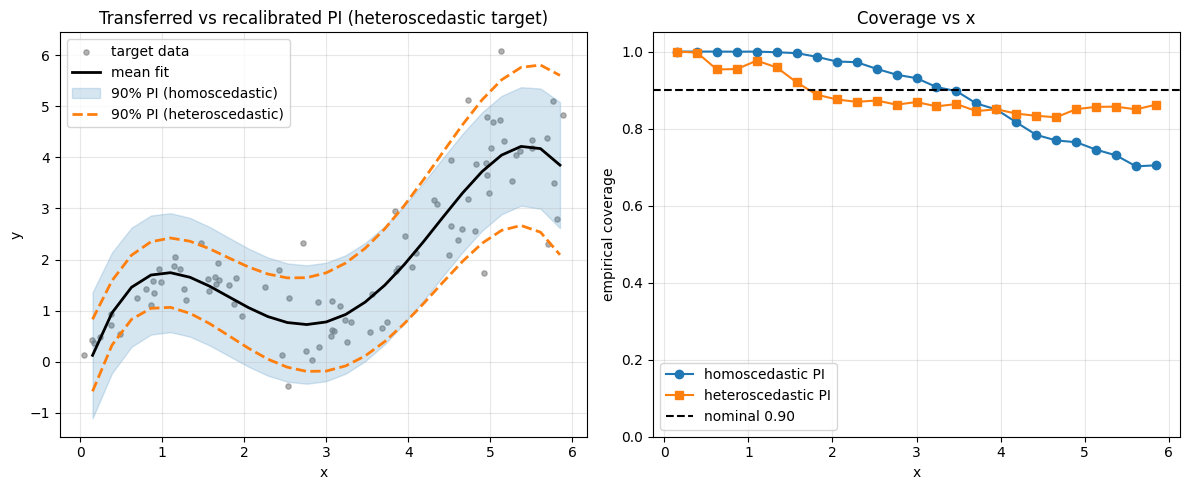

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(xtr, ytr, s=14, c='gray', alpha=.6, label='target data')
ax.plot(xq, mean_pred(xq), 'k-', lw=2, label='mean fit')
lo1, hi1 = PI_homo(xq); lo2, hi2 = PI_hetero(xq)
ax.fill_between(xq, lo1, hi1, alpha=.18, color='C0', label='90% PI (homoscedastic)')
ax.plot(xq, lo2, '--', color='C1', lw=2)
ax.plot(xq, hi2, '--', color='C1', lw=2, label='90% PI (heteroscedastic)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Transferred vs recalibrated PI (heteroscedastic target)')
ax.legend(); ax.grid(alpha=.3)

ax = axes[1]
ax.plot(xq, cov_homo, 'o-', color='C0', label='homoscedastic PI')
ax.plot(xq, cov_het,  's-', color='C1', label='heteroscedastic PI')
ax.axhline(0.90, ls='--', color='k', label='nominal 0.90')
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('x'); ax.set_ylabel('empirical coverage')
ax.set_title('Coverage vs x')
ax.legend(); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **균일분산 PI의 폭은 거의 상수**다(가장자리에서 레버리지 $h$ 때문에 조금 넓어질 뿐). 반면 target의 실제 잡음 $\sigma(x)$ 는
   왼쪽→오른쪽으로 커진다. 그래서 밴드가 잡음의 변화를 따라가지 못한다.
2. **고잡음 영역(오른쪽)에서 under-cover**: 실제 산포가 밴드보다 커서 경험적 피복률이 0.90 아래로 떨어진다.
3. **저잡음 영역(왼쪽)에서 over-cover**: 밴드가 필요 이상으로 넓어 피복률이 0.90 위로 뜬다 — 안전해 보이지만 정보가 낭비된다.
4. **이분산 PI의 회복**: $\ln r^2 \sim x$ 로 복원한 $\hat\sigma^2(x)$ 를 쓰면 밴드가 $x$ 에 따라 좁아졌다 넓어지고,
   피복률이 전 구간에서 0.90 근처로 평탄해진다. 전체 평균 피복률도 목표에 가까워진다.

> **결론**: 불확실성 정량화는 **잡음 구조 가정**을 함께 전이한다. 도메인이 이분산으로 바뀌면 평균모형이 옳아도
> PI는 오보정되므로, **분산함수 $\sigma^2(x)$ 를 target 데이터로 재추정**해야 피복률이 회복된다.

**다음 문제로의 연결** — 복잡도(Problem 1)와 불확실성(Problem 2)을 맞췄다면, 남은 손잡이는 **하이퍼파라미터**다.
Problem 3에서 source에서 얻은 튜닝 경험을 **warm-start** 로 target 베이지안 최적화에 전이하고, *양의 전이*와 *음의 전이*를 비교한다.